# Pneumonia Detection from Chest X-Ray Images using Transfer Learning

This notebook builds an AI system that classifies chest X-ray images as **NORMAL** or **PNEUMONIA**
using transfer learning (a pretrained CNN backbone fine-tuned on the target dataset).

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) by Paul Mooney (Kaggle)

**Pipeline:**
1. Download / load the dataset
2. Explore class distribution
3. Build data pipelines with augmentation
4. Transfer learning with a pretrained backbone (MobileNetV2, easily swappable for VGG16/ResNet50/DenseNet121)
5. Train the classification head (frozen backbone)
6. Fine-tune the top backbone layers (unfrozen, low learning rate)
7. Evaluate: accuracy, precision, recall, F1, confusion matrix, ROC-AUC
8. Visualize predictions and save the trained model

> **Note on compute:** This dataset (~5,800 images) trains reasonably on a single GPU in ~15-30 min per stage.
> On CPU it will be much slower — consider running this in Kaggle Notebooks, Google Colab (free GPU), or a local
> machine with a GPU.


## 1. Setup & Imports

In [4]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.3.0-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


ImportError: cannot import name 'VGG16' from 'tensorflow.keras.models' (c:\Users\Faisal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\_tf_keras\keras\models\__init__.py)

## 2. Get the Dataset

Two options — pick whichever fits your environment.

**Option A — Kaggle API (recommended, works in any notebook environment with internet):**
Requires a `kaggle.json` API token (from your Kaggle account -> Settings -> Create New Token).


In [4]:
# OPTION A: Download via Kaggle API
# Uncomment and run once. Place kaggle.json in ~/.kaggle/ first, or upload it in this session.

# !pip install kaggle --quiet
# import os
# os.environ['KAGGLE_CONFIG_DIR'] = os.path.expanduser('~/.kaggle')  # folder containing kaggle.json
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p ./data --unzip


**Option B — Already have the data locally / running on Kaggle Notebooks:**
The dataset ships with this folder structure:

```
chest_xray/
    train/
        NORMAL/
        PNEUMONIA/
    val/
        NORMAL/
        PNEUMONIA/
    test/
        NORMAL/
        PNEUMONIA/
```

If you're running this **inside a Kaggle Notebook** with the dataset attached, the path is usually:
`/kaggle/input/chest-xray-pneumonia/chest_xray`

Set `DATA_DIR` below to wherever your `chest_xray` folder lives.


In [3]:
# Set this to the root folder that contains train/val/test
DATA_DIR = "chest_xray/"   # <-- change if needed
# e.g. on Kaggle: DATA_DIR = "/kaggle/input/chest-xray-pneumonia/chest_xray"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

assert os.path.isdir(TRAIN_DIR), f"Train folder not found at {TRAIN_DIR} — set DATA_DIR correctly."
print("Data directory OK:", DATA_DIR)


Data directory OK: chest_xray/


## 3. Explore Class Distribution

The original Kaggle `val` split only has 16 images (8 per class), which is too small to be a
reliable validation set. We merge `train` + `val` and carve out a proper stratified validation split.


In [4]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                                if f.lower().endswith(('.jpeg', '.jpg', '.png'))])
    return counts

for split, path in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    print(split.upper(), count_images(path))


TRAIN {'NORMAL': 12, 'PNEUMONIA': 12}
VAL {'NORMAL': 8, 'PNEUMONIA': 8}
TEST {'NORMAL': 11, 'PNEUMONIA': 11}


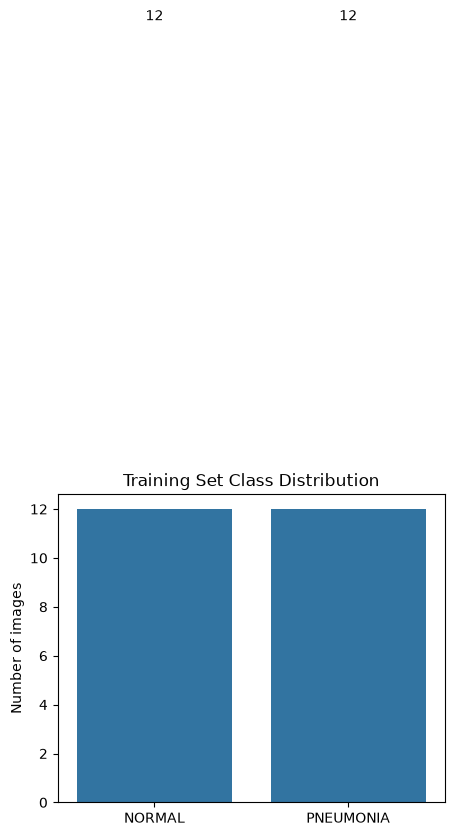

In [5]:
counts = count_images(TRAIN_DIR)
plt.figure(figsize=(5,4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Training Set Class Distribution")
plt.ylabel("Number of images")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 20, str(v), ha='center')
plt.show()

# Class imbalance is expected: PNEUMONIA >> NORMAL in this dataset.
# We'll handle it with class_weight during training.


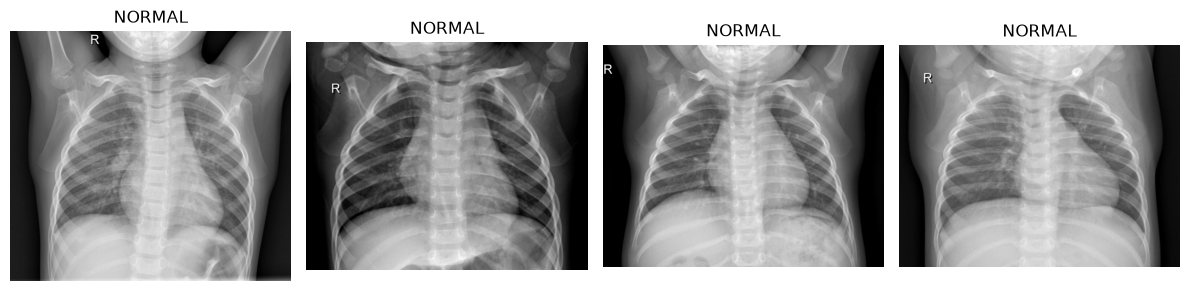

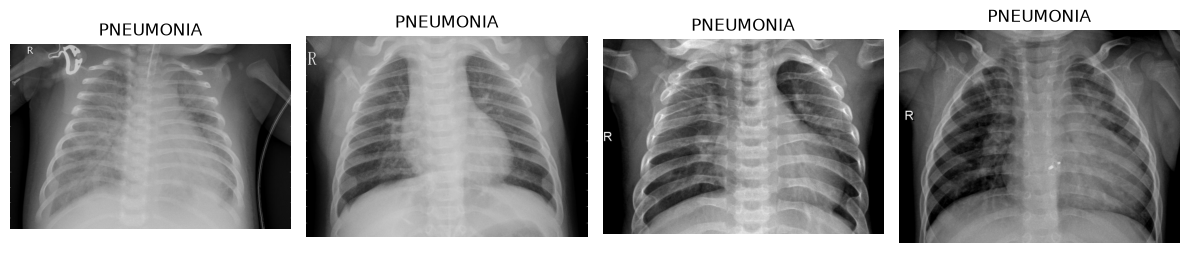

In [6]:
# Peek at a few sample images
def show_samples(folder, cls, n=4):
    cls_path = os.path.join(folder, cls)
    files = os.listdir(cls_path)[:n]
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, f in zip(axes, files):
        img = keras.utils.load_img(os.path.join(cls_path, f), color_mode='grayscale')
        ax.imshow(img, cmap='gray')
        ax.set_title(cls)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, "NORMAL")
show_samples(TRAIN_DIR, "PNEUMONIA")


## 4. Data Pipelines (Augmentation + Rescaling)

We rebuild `train`/`val` from the `train` folder with an 85/15 stratified split (since Kaggle's
`val` folder is too small), and keep `test` untouched as the final held-out evaluation set.


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=False,   # chest X-rays: flipping can be anatomically misleading, keep off
    brightness_range=[0.85, 1.15],
    validation_split=0.15,
    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=SEED
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
# {'NORMAL': 0, 'PNEUMONIA': 1}


Found 22 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 22 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [13]:
# Handle class imbalance
labels = train_gen.classes
class_weights = compute_class_weight(class_weight='balanced',
                                      classes=np.unique(labels),
                                      y=labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


## 5. Build the Model (Transfer Learning)

We use **MobileNetV2** pretrained on ImageNet as the feature extractor. It's lightweight and fast —
swap it for `VGG16`, `ResNet50`, or `DenseNet121` (from `tensorflow.keras.applications`) if you want
to compare backbones; the rest of the pipeline stays the same.

**Stage 1:** freeze the backbone, train only the new classification head.
**Stage 2:** unfreeze the top backbone layers and fine-tune with a low learning rate.


In [14]:
def build_model(input_shape=(224,224,3)):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Freeze the base model for transfer learning  
    base_model.trainable = False  # freeze for stage 1
    inputs = keras.Input(shape=input_shape)

    #Keep the base model frozen for now, we'll unfreeze later for fine-tuning
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    #Final output layer for binary classification (NORMAL vs PNEUMONIA)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(input_shape=(*IMG_SIZE, 3))
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)


## 6. Stage 1 — Train the Classification Head

In [16]:
os.makedirs("checkpoints", exist_ok=True)

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint('checkpoints/stage1_best.keras', monitor='val_auc',
                                     mode='max', save_best_only=True)
]

EPOCHS_STAGE1 = 15

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)


Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5455 - auc: 0.6240 - loss: 0.7200 - precision: 0.5556 - recall: 0.4545 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.5747 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6818 - auc: 0.7397 - loss: 0.5833 - precision: 0.6667 - recall: 0.7273 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.5635 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7727 - auc: 0.9132 - loss: 0.3947 - precision: 0.8000 - recall: 0.7273 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.5909 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7273 - auc: 0.8760 - loss: 0.4642 - precision: 0.7778 - recall: 0.6364 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.3454 - val_precision: 1.0000 -

## 7. Stage 2 — Fine-Tune the Backbone

Unfreeze the last ~30 layers of MobileNetV2 and continue training with a much smaller learning rate
so we don't destroy the pretrained ImageNet features.


In [17]:
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint('checkpoints/stage2_finetuned.keras', monitor='val_auc',
                                     mode='max', save_best_only=True)
]

EPOCHS_STAGE2 = 10

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.6818 - auc: 0.6983 - loss: 0.6609 - precision: 0.6667 - recall: 0.7273 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.5728 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4545 - auc: 0.4669 - loss: 0.8790 - precision: 0.4615 - recall: 0.5455 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.7320 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4545 - auc: 0.5909 - loss: 0.7172 - precision: 0.4444 - recall: 0.3636 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.4602 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - auc: 0.5620 - loss: 0.7884 - precision: 0.5000 - recall: 0.5455 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.9577 - v

## 8. Training Curves

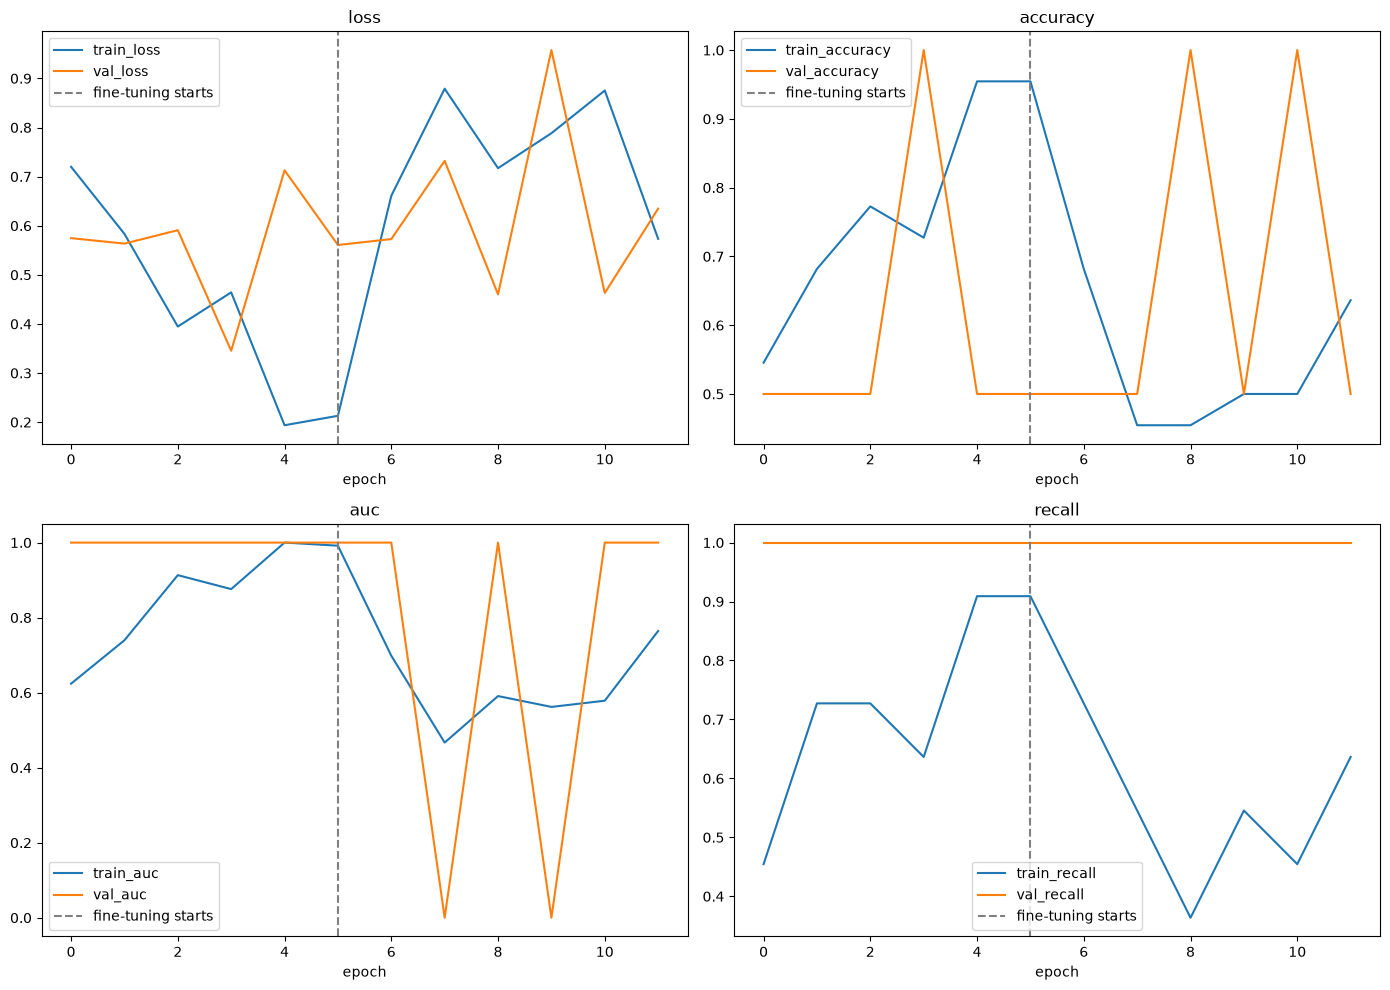

In [18]:
def plot_history(h1, h2, metric):
    vals = h1.history[metric] + h2.history[metric]
    val_vals = h1.history[f'val_{metric}'] + h2.history[f'val_{metric}']
    split = len(h1.history[metric])

    plt.plot(vals, label=f'train_{metric}')
    plt.plot(val_vals, label=f'val_{metric}')
    plt.axvline(split - 1, color='gray', linestyle='--', label='fine-tuning starts')
    plt.title(metric)
    plt.xlabel('epoch')
    plt.legend()

plt.figure(figsize=(14, 10))
for i, metric in enumerate(['loss', 'accuracy', 'auc', 'recall'], 1):
    plt.subplot(2, 2, i)
    plot_history(history1, history2, metric)
plt.tight_layout()
plt.show()


## 9. Final Evaluation on the Held-Out Test Set

In [19]:
test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(test_gen)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test AUC:       {test_auc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step - accuracy: 0.5455 - auc: 0.9256 - loss: 0.6743 - precision: 0.5238 - recall: 1.0000
Test Accuracy:  0.5455
Test Precision: 0.5238
Test Recall:    1.0000
Test AUC:       0.9256


In [20]:
# Predictions
y_true = test_gen.classes
y_pred_prob = model.predict(test_gen).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

class_names = list(test_gen.class_indices.keys())  # ['NORMAL', 'PNEUMONIA']
print(classification_report(y_true, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      NORMAL       1.00      0.09      0.17        11
   PNEUMONIA       0.52      1.00      0.69        11

    accuracy                           0.55        22
   macro avg       0.76      0.55      0.43        22
weighted avg       0.76      0.55      0.43        22



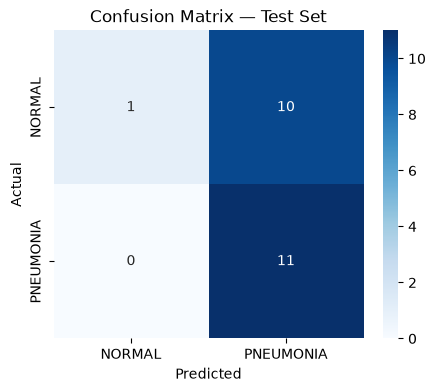

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.show()


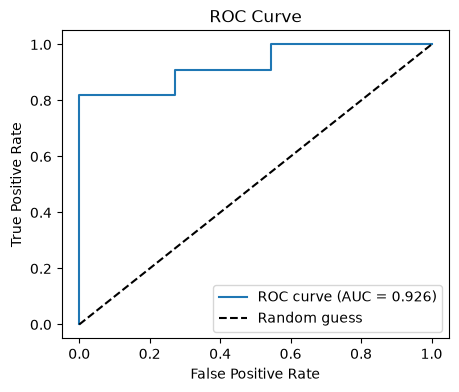

In [22]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


**Note on clinical framing:** In pneumonia screening, missing a true pneumonia case (false negative)
is usually costlier than a false alarm (false positive). If recall on the PNEUMONIA class matters more
than raw accuracy, consider lowering the decision threshold below 0.5 and re-checking the
precision/recall trade-off using the curve below.

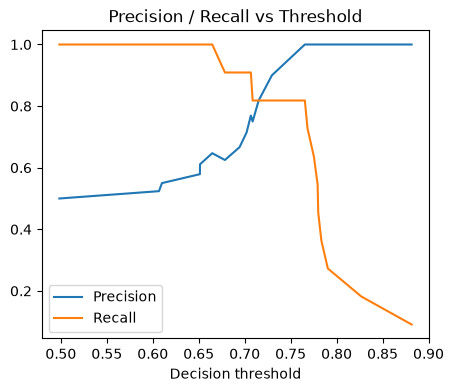

In [23]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_pred_prob)

plt.figure(figsize=(5,4))
plt.plot(thresholds, precision_vals[:-1], label='Precision')
plt.plot(thresholds, recall_vals[:-1], label='Recall')
plt.xlabel('Decision threshold')
plt.title('Precision / Recall vs Threshold')
plt.legend()
plt.show()


## 10. Visualize Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


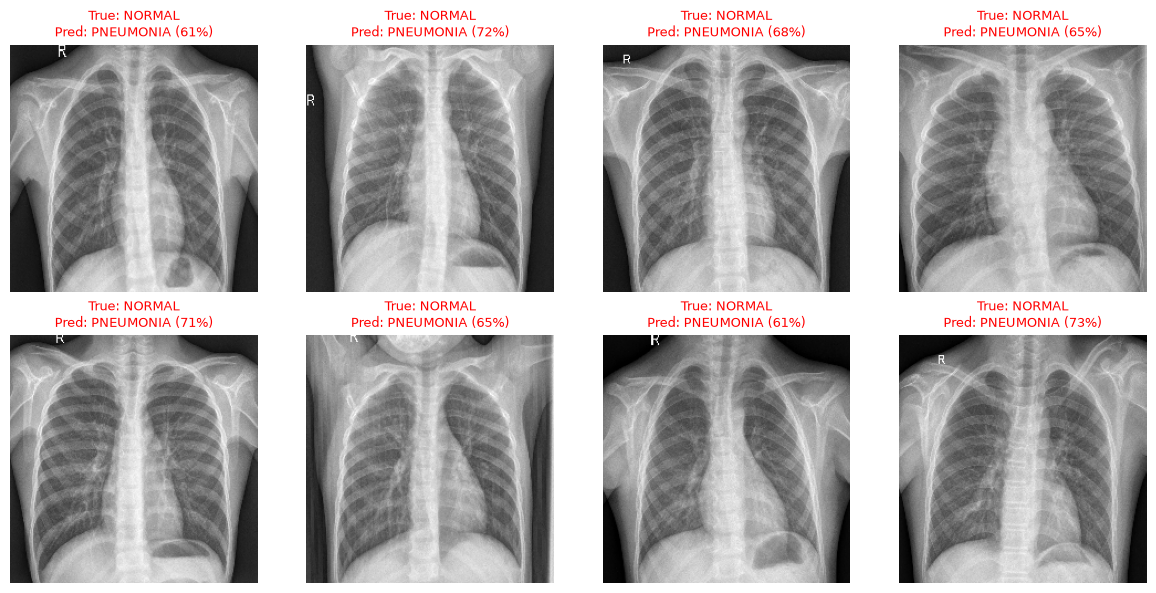

In [24]:
def visualize_predictions(generator, model, n=8):
    generator.reset()
    x_batch, y_batch = next(generator)
    preds = model.predict(x_batch).ravel()

    fig, axes = plt.subplots(2, n//2, figsize=(3*(n//2), 6))
    for i, ax in enumerate(axes.ravel()):
        if i >= len(x_batch):
            break
        img = x_batch[i]
        true_label = class_names[int(y_batch[i])]
        pred_label = class_names[int(preds[i] >= 0.5)]
        confidence = preds[i] if preds[i] >= 0.5 else 1 - preds[i]
        color = 'green' if true_label == pred_label else 'red'

        ax.imshow(img)
        ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0%})", color=color, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(test_gen, model)


## 11. Save the Trained Model

In [25]:
model.save("pneumonia_detector_mobilenetv2.keras")
print("Model saved to pneumonia_detector_mobilenetv2.keras")

# To reload later:
# loaded_model = keras.models.load_model("pneumonia_detector_mobilenetv2.keras")


Model saved to pneumonia_detector_mobilenetv2.keras


## 12. Inference on a Single New Image

In [26]:
def predict_single_image(img_path, model, img_size=IMG_SIZE, threshold=0.5):
    img = keras.utils.load_img(img_path, target_size=img_size)
    arr = keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob = model.predict(arr)[0][0]
    label = "PNEUMONIA" if prob >= threshold else "NORMAL"
    confidence = prob if prob >= threshold else 1 - prob

    plt.imshow(img)
    plt.title(f"Prediction: {label} ({confidence:.1%} confidence)")
    plt.axis('off')
    plt.show()

    return label, float(confidence)

# Example usage:
# predict_single_image("path/to/some_xray.jpeg", model)


## Summary & Next Steps

- **Approach:** Transfer learning with MobileNetV2 (ImageNet weights) → frozen-backbone head training →
  fine-tuning top layers at a low learning rate.
- **Imbalance handling:** class weights computed from the training distribution.
- **Evaluation:** accuracy, precision, recall, AUC, confusion matrix, ROC and precision-recall curves.

**Ideas to improve further:**
- Try other backbones (`DenseNet121`, `EfficientNetB0`) and compare AUC/recall.
- Use `tf.data` pipelines with `tf.keras.applications.mobilenet_v2.preprocess_input` for backbone-specific normalization instead of a plain `1/255` rescale.
- Apply Grad-CAM to visualize which lung regions the model focuses on (useful for clinical interpretability).
- K-fold cross-validation on the merged train+val set for a more robust performance estimate.
- Calibrate the decision threshold based on the precision/recall trade-off relevant to the clinical use case.

**Disclaimer:** This is a research/educational pipeline, not a certified diagnostic tool. Clinical deployment would require regulatory validation, a much larger and more diverse dataset, and clinician oversight.
